## 5. 리스트
### 5.1 리스트의 정의
- 기본적인 형태는 p개의 벡터로 구성되는 데이터 객체 형태
- 리스트의 각 성분(벡터)은 독립적임. 길이나 형식이 달라도 무방
- 리스트는 list()를 이용하여 만든다

In [ ]:
members = list(leaders = c("park","choi"),assistants = "kang",workers = c("lee","kim","hong","song"),number=c(4,6))
print(members)

$leaders
[1] "park" "choi"

$assistants
[1] "kang"

$workers
[1] "lee"  "kim"  "hong" "song"

$number
[1] 4 6



In [ ]:
print(class(members)); print(names(members)) ;

length(members) ; print(mode(members))

[1] "list"
[1] "leaders"    "assistants" "workers"    "number"    


[1] 4

[1] "list"


### 5.2 리스트의 인덱싱
- 인덱싱(indexing): 리스트의 구성요소에 접근하는 방법.
- 예: [[]], 이름, $의 사용

In [ ]:
print(members[[1]])
print(members[["leaders"]])
print(class(members[["leaders"]]))
print(mode(members[["leaders"]]))

[1] "park" "choi"
[1] "park" "choi"
[1] "character"
[1] "character"


In [ ]:
print(members[[c(3,4)]]) ; print(members[[3]][4])

[1] "song"
[1] "song"


### 5.3 재귀리스트
- 리스트를 하위 구성요소로 가지는 리스트를 만들 수 있다.

In [ ]:
salaries <- list(leaders = c(250, 200), assistant = 100, members = c(300, 200, 180, 120, 100))
team <- list(m = members, s = salaries)
print(team)
team.1 <- c(m = members, s = salaries) # m과 s의 형식이 풀려서 리스트로 저장
print(team.1)
print(class(team.1))

$m
$m$leaders
[1] "park" "choi"

$m$assistants
[1] "kang"

$m$workers
[1] "lee"  "kim"  "hong" "song"

$m$number
[1] 4 6


$s
$s$leaders
[1] 250 200

$s$assistant
[1] 100

$s$members
[1] 300 200 180 120 100


$m.leaders
[1] "park" "choi"

$m.assistants
[1] "kang"

$m.workers
[1] "lee"  "kim"  "hong" "song"

$m.number
[1] 4 6

$s.leaders
[1] 250 200

$s.assistant
[1] 100

$s.members
[1] 300 200 180 120 100

[1] "list"


### 5.4 리스트에 함수 적용하기
- 리스트의 각 요소들에 특정한 함수를 간편하게 적용할 수 있다
- 예: lapply()함수 적용하기 (결과는 같은 구조의 리스트로 출력됨)

In [ ]:
print(lapply(salaries, median)) ; # salaries$leaders = c('a','b')
print(lapply(salaries, median))

$leaders
[1] 225

$assistant
[1] 100

$members
[1] 180

$leaders
[1] 225

$assistant
[1] 100

$members
[1] 180



In [ ]:
print(sapply(salaries, median))
print(class(sapply(salaries, median)))

  leaders assistant   members 
      225       100       180 
[1] "numeric"


In [ ]:
print(sapply(salaries, range))

     leaders assistant members
[1,]     200       100     100
[2,]     250       100     300


### 5.5 내부구조 없애기

- unlist()는 리스트의 내부 구조를 없애준다.

In [ ]:
print(median(unlist(salaries)))
# salaries$leaders = c('a','b')
print(unlist(salaries))

[1] 190
 leaders1  leaders2 assistant  members1  members2  members3  members4  members5 
      250       200       100       300       200       180       120       100 


##**과제8**##

리스트로 지정된 salaries의 각 객체의 평균, 표준편차를 계산하고 이를 각각의 성분으로 하는 행렬을 출력하시오

(첫번째 행의 첫번째 열과 두번째 열에 첫번째 객체의 평균과 표준편차를 저장)

In [ ]:
salaries <- list(leaders = c(250, 200), assistant = 100, members = c(300, 200, 180, 120, 100))


In [ ]:
# salaries 리스트 정의
salaries <- list(leaders = c(250, 200), assistant = 100, members = c(300, 200, 180, 120, 100))

# 각 성분에 대해 평균과 표준편차 계산
stats_results <- sapply(salaries, function(x) c(mean = mean(x), sd = sd(x)))

# 행과 열 이름 설정
rownames(stats_results) <- c("Mean", "Standard Deviation")
colnames(stats_results) <- names(salaries)

# 결과 출력
print(stats_results)

                     leaders assistant   members
Mean               225.00000       100 180.00000
Standard Deviation  35.35534        NA  78.74008


In [ ]:
# salaries 리스트 정의
salaries <- list(leaders = c(250, 200), assistant = 100, members = c(300, 200, 180, 120, 100))

# 각 성분에 대해 평균과 표준편차 계산
stats_results <- sapply(salaries, function(x) c(mean = mean(x), sd = sd(x)))

# 행과 열을 전치
transposed_stats <- t(stats_results)

# 결과 출력
print(transposed_stats)


          mean       sd
leaders    225 35.35534
assistant  100       NA
members    180 78.74008


In [ ]:
salaries <- list(leaders = c(250, 200),
                 assistant = 100,
                 members = c(300, 200, 180, 120, 100))
result_matrix <- matrix(nrow = length(salaries), ncol = 2)
colnames(result_matrix) <- c("Mean", "SD")
rownames(result_matrix) <- names(salaries)

for (i in seq_along(salaries)) {
  result_matrix[i, 1] <- mean(salaries[[i]])
  result_matrix[i, 2] <- sd(salaries[[i]])
}
print(result_matrix)

          Mean       SD
leaders    225 35.35534
assistant  100       NA
members    180 78.74008


## 6. R 인자와 데이터 요약
- R에서 인자(factor)는 범주형 변수 혹은 비연속적 변수를 나타낸다
### 6.1 인자와 테이블

In [ ]:
set.seed(1)
alpha = sample(c("A", "B", "C"), 25, replace=T)
f = factor(alpha) ; print(f) #Levels
print(mode(alpha)) ;
print(paste('f:',mode(f))) ; print(paste('f',class(f)))

 [1] A C A B A C C B B C C A A A B B B B C A C A A A A
Levels: A B C
[1] "character"
[1] "f: numeric"
[1] "f factor"


In [ ]:
print(unclass(f)) # 범주형을 숫자로 풀어냄

 [1] 1 3 1 2 1 3 3 2 2 3 3 1 1 1 2 2 2 2 3 1 3 1 1 1 1
attr(,"levels")
[1] "A" "B" "C"


- table()은 인자 변수의 1원, 2원 빈도표를 만들어 준다.
- addmargins()는 빈도표의 주변 합을 테이블에 추가한다.

In [ ]:
table(f) ; addmargins(table(f))

f
 A  B  C 
11  7  7 

f
  A   B   C Sum 
 11   7   7  25 

In [ ]:
z = sample(1:5, 25, replace=T)
g = factor(z)
str(g)
tab = table(f, g);  print(addmargins(tab))

 Factor w/ 5 levels "1","2","3","4",..: 5 5 2 2 1 4 1 4 3 2 ...
     g
f      1  2  3  4  5 Sum
  A    2  3  1  3  2  11
  B    2  2  1  2  0   7
  C    1  3  0  2  1   7
  Sum  5  8  2  7  3  25


In [ ]:
print(dim(tab))

[1] 3 5


### 6.2 데이터 요약하기
- tapply()는 자료를 수준별로 나누어 함수를 적용한다.

In [ ]:
set.seed(2)
x = round(rnorm(25, 50, 10))
print(f)
print(tapply(x,f,mean))

 [1] A C A B A C C B B C C A A A B B B B C A C A A A A
Levels: A B C
       A        B        C 
52.72727 51.57143 56.28571 


In [ ]:
g = tapply(x, f, function(t) max(t)-min(t)) ; print(g)

 A  B  C 
32 43 22 


- 자료가 리스트인 경우 sapply()함수를 사용할 수 있음.


In [ ]:
s = cbind(x,z)
print(f) ; uf = unclass(f)
g = list(A = s[uf==1,1:2], B = s[uf==2,1:2], C = s[uf==3,1:2])
print( sapply(g, apply, 2, median) ) # median 은 열별로 출력의 차원이 2가 됨

 [1] A C A B A C C B B C C A A A B B B B C A C A A A A
Levels: A B C
   A  B  C
x 50 50 54
z  3  2  2


- aggregate()함수는 수준별로 나누어 함수를 적용한다.


In [ ]:
print(x)
a = aggregate(cbind(x, z)[,1], list(f), sum)
print(a)

 [1] 41 52 66 39 49 51 57 48 70 49 54 60 46 40 68 27 59 50 60 54 71 38 66 70 50
  Group.1   x
1       A 580
2       B 361
3       C 394


In [ ]:
z = sample(1:5, 25, replace=T)
g = factor(z)
print(aggregate(cbind(x, z)[,1], list(f,g), sum))

   Group.1 Group.2   x
1        A       1  87
2        B       1  48
3        C       1  51
4        A       2 217
5        B       2 129
6        A       3  50
7        B       3  39
8        C       3  52
9        A       4 166
10       B       4  50
11       C       4 180
12       A       5  60
13       B       5  95
14       C       5 111


### 6.3 자료의 구간화
- 수치형 벡터를 구간화하여 범주화할 수 있다.
- cut()는 수치형 벡터를 구간화 한다.

In [ ]:
set.seed(1)
x = runif(100,0,10)
y = 5 + 0.5*(x-5) + rnorm(100)
x.cut = cut(x, 0:10)
print(x)
print(x.cut)

  [1] 2.6550866 3.7212390 5.7285336 9.0820779 2.0168193 8.9838968 9.4467527
  [8] 6.6079779 6.2911404 0.6178627 2.0597457 1.7655675 6.8702285 3.8410372
 [15] 7.6984142 4.9769924 7.1761851 9.9190609 3.8003518 7.7744522 9.3470523
 [22] 2.1214252 6.5167377 1.2555510 2.6722067 3.8611409 0.1339033 3.8238796
 [29] 8.6969085 3.4034900 4.8208012 5.9956583 4.9354131 1.8621760 8.2737332
 [36] 6.6846674 7.9423986 1.0794363 7.2371095 4.1127443 8.2094629 6.4706019
 [43] 7.8293276 5.5303631 5.2971958 7.8935623 0.2333120 4.7723007 7.3231374
 [50] 6.9273156 4.7761962 8.6120948 4.3809711 2.4479728 0.7067905 0.9946616
 [57] 3.1627171 5.1863426 6.6200508 4.0683019 9.1287592 2.9360337 4.5906573
 [64] 3.3239467 6.5087047 2.5801678 4.7854525 7.6631067 0.8424691 8.7532133
 [71] 3.3907294 8.3944035 3.4668349 3.3377493 4.7635125 8.9219834 8.6433947
 [78] 3.8998954 7.7732070 9.6061800 4.3465948 7.1251468 3.9999437 3.2535215
 [85] 7.5708715 2.0269226 7.1112122 1.2169192 2.4548851 1.4330438 2.3962942
 [92] 0.5893

In [ ]:
print(head(cbind(x, x.cut)))

            x x.cut
[1,] 2.655087     3
[2,] 3.721239     4
[3,] 5.728534     6
[4,] 9.082078    10
[5,] 2.016819     3
[6,] 8.983897     9


In [ ]:
y.local <- aggregate(y, list(x.cut), mean)
print(y.local)

   Group.1        x
1    (0,1] 2.926815
2    (1,2] 2.653347
3    (2,3] 3.468511
4    (3,4] 4.111206
5    (4,5] 5.057965
6    (5,6] 5.954442
7    (6,7] 5.659047
8    (7,8] 6.172075
9    (8,9] 6.989410
10  (9,10] 7.124902


In [ ]:
library(MASS)

##**과제9**##

- MASS 패키지의 Cars93 데이터셋을 Origin 변수값에 의해 두 그룹으로 분할하시오.
- Origin 변수에 대한 빈도표를 만드시오.
- Origin 별로 Price 변수의 평균값을 계산하되 tapply()와 aggregate()를 이용하시오.

In [ ]:
library(MASS)
cars_split <- split(Cars93, Cars93$Origin)
cars_split

,Manufacturer,Model,Type,Min.Price,Price,Max.Price,MPG.city,MPG.highway,AirBags,DriveTrain,⋯,Passengers,Length,Wheelbase,Width,Turn.circle,Rear.seat.room,Luggage.room,Weight,Origin,Make
,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<int>,<int>,<fct>,<fct>,⋯,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<fct>,<fct>
6,Buick,Century,Midsize,14.2,15.7,17.3,22,31,Driver only,Front,⋯,6,189,105,69,41,28.0,16,2880,USA,Buick Century
7,Buick,LeSabre,Large,19.9,20.8,21.7,19,28,Driver only,Front,⋯,6,200,111,74,42,30.5,17,3470,USA,Buick LeSabre
8,Buick,Roadmaster,Large,22.6,23.7,24.9,16,25,Driver only,Rear,⋯,6,216,116,78,45,30.5,21,4105,USA,Buick Roadmaster
9,Buick,Riviera,Midsize,26.3,26.3,26.3,19,27,Driver only,Front,⋯,5,198,108,73,41,26.5,14,3495,USA,Buick Riviera
10,Cadillac,DeVille,Large,33.0,34.7,36.3,16,25,Driver only,Front,⋯,6,206,114,73,43,35.0,18,3620,USA,Cadillac DeVille
11,Cadillac,Seville,Midsize,37.5,40.1,42.7,16,25,Driver & Passenger,Front,⋯,5,204,111,74,44,31.0,14,3935,USA,Cadillac Seville
12,Chevrolet,Cavalier,Compact,8.5,13.4,18.3,25,36,None,Front,⋯,5,182,101,66,38,25.0,13,2490,USA,Chevrolet Cavalier
13,Chevrolet,Corsica,Compact,11.4,11.4,11.4,25,34,Driver only,Front,⋯,5,184,103,68,39,26.0,14,2785,USA,Chevrolet Corsica
14,Chevrolet,Camaro,Sporty,13.4,15.1,16.8,19,28,Driver & Passenger,Rear,⋯,4,193,101,74,43,25.0,13,3240,USA,Chevrolet Camaro


In [ ]:
cars_split <- split(Cars93, Cars93$Origin)
cars_split

In [ ]:
origin_frequency <- table(Cars93$Origin)

In [ ]:
origin_frequency


    USA non-USA 
     48      45 

In [ ]:
# tapply()를 사용하여 Origin 별 Price 평균값 계산
price_mean_tapply <- tapply(Cars93$Price, Cars93$Origin, mean)

# 결과 출력
print(price_mean_tapply)

# aggregate()를 사용하여 Origin 별 Price 평균값 계산
price_mean_aggregate <- aggregate(Price ~ Origin, data = Cars93, FUN = mean)

# 결과 출력
print(price_mean_aggregate)

     USA  non-USA 
18.57292 20.50889 
   Origin    Price
1     USA 18.57292
2 non-USA 20.50889


## **7. 루프 및 제어 프로그래밍**
- 반복문, 제어문, 사용자 정의함수를 다룬다.

### 7.1 반복문 for
- 특정한 작업을 주어진 case에 대해서 반복한다
- 예 : $\sum_{i=1}^{10} i^4$


In [ ]:
temp <- 0
for (i in 1:10) {
  temp <- temp + i^4
  print(paste('Loop:',i,'Temp:',temp))
  }

[1] "Loop: 1 Temp: 1"
[1] "Loop: 2 Temp: 17"
[1] "Loop: 3 Temp: 98"
[1] "Loop: 4 Temp: 354"
[1] "Loop: 5 Temp: 979"
[1] "Loop: 6 Temp: 2275"
[1] "Loop: 7 Temp: 4676"
[1] "Loop: 8 Temp: 8772"
[1] "Loop: 9 Temp: 15333"
[1] "Loop: 10 Temp: 25333"


예 : $x=10,7,4,1$에 대해서 $\sqrt{x}$의 합

In [ ]:
temp <- 0
for(x in c(10, 7, 4, 1)) {
 temp <- temp + sqrt(x)
 print(temp)
 }

[1] 3.162278
[1] 5.808029
[1] 7.808029
[1] 8.808029


In [ ]:
temp = 0
rs = c()
for(x in c(10, 7, 4, 1)) {

 temp <- temp + sqrt(x)
 print(temp)
 rs = c(rs, temp)
 }

 print(rs)

[1] 3.162278
[1] 5.808029
[1] 7.808029
[1] 8.808029
[1] 3.162278 5.808029 7.808029 8.808029


In [ ]:
temp = 0
rs = c()
for(x in seq(1,10, length=90))
{
 temp <- temp + sqrt(x)/9
 # print(temp)
 rs = c(rs, temp)
 }
print(rs)

 [1]  0.1111111  0.2277049  0.3495350  0.4763853  0.6080646  0.7444019
 [7]  0.8852434  1.0304493  1.1798922  1.3334554  1.4910310  1.6525194
[13]  1.8178281  1.9868706  2.1595664  2.3358397  2.5156193  2.6988382
[19]  2.8854329  3.0753435  3.2685130  3.4648874  3.6644152  3.8670474
[25]  4.0727370  4.2814393  4.4931115  4.7077124  4.9252026  5.1455442
[31]  5.3687008  5.5946373  5.8233199  6.0547160  6.2887943  6.5255242
[37]  6.7648765  7.0068226  7.2513351  7.4983874  7.7479535  8.0000085
[43]  8.2545279  8.5114882  8.7708663  9.0326400  9.2967875  9.5632876
[49]  9.8321198 10.1032641 10.3767009 10.6524110 10.9303760 11.2105777
[55] 11.4929983 11.7776206 12.0644276 12.3534029 12.6445303 12.9377941
[61] 13.2331786 13.5306689 13.8302502 14.1319079 14.4356278 14.7413961
[67] 15.0491991 15.3590234 15.6708560 15.9846840 16.3004948 16.6182760
[73] 16.9380154 17.2597012 17.5833217 17.9088653 18.2363207 18.5656770
[79] 18.8969230 19.2300482 19.5650420 19.9018940 20.2405940 20.5811321
[85] 2

In [ ]:
temp = 0
rs = c()
for(x in seq(1,10, length=90))
{
for ( y in 1:10)
{
 temp <- temp + sqrt(x+y)/9
 # print(temp)
 rs = c(rs, temp)
 }
}
print(temp)

[1] 325.8357


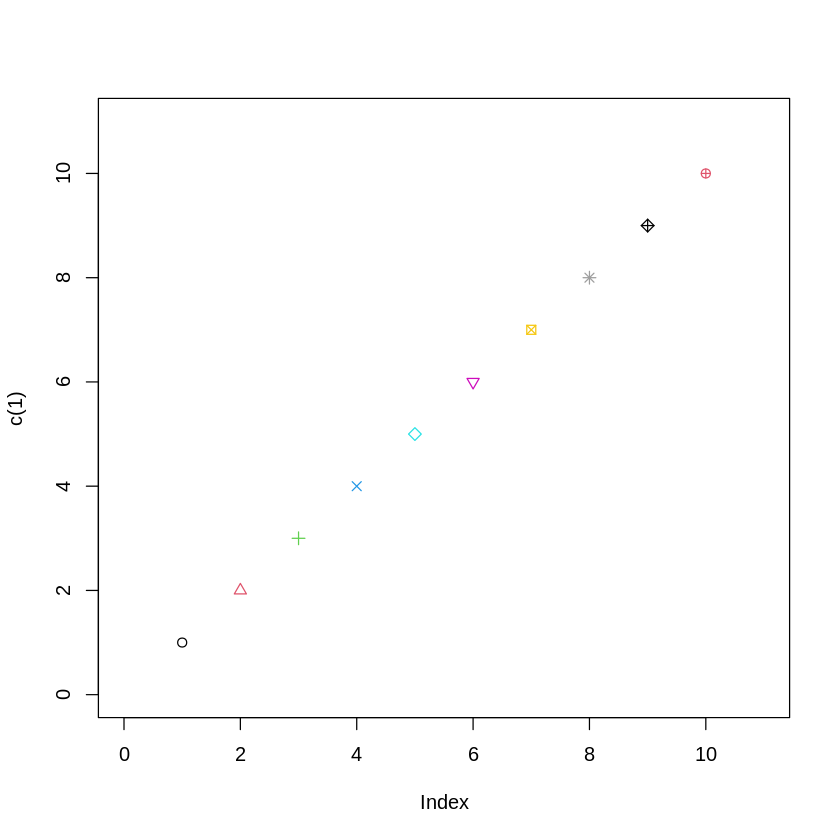

In [ ]:
 plot(c(1)~1, lty=1, pch=1, col=1, cex=1, xlim=c(0,11), ylim=c(0,11))
for ( i in 2:10)
{
  for (l in 1:10**8)
  { }
  points(i, i, lty=i, pch=i, col=i, cex=1)
}

### 7.2 반복문 while
- 특정 조건을 만족하는 한 어떤 작업을 계속 수행하도록 한다.
- 예: $\sum_{i=1}^{K} i^4$을 $i^4 < 100000$이 만족되는 $K$ 까지만 수행

In [ ]:
# while
temp <- 0
i <- 0
while (i^4 < 100000) {
temp <- temp + i^4
i = i + 1
 }
print(c(i-1, temp))

[1]     17 327369


In [ ]:
# repeate & if
temp <- 0
i <- 1
repeat {
 if (i^4 >= 100000) break
 temp <- temp + i^4
 i <- i+1
 }
print(c(i-1, temp))

[1]     17 327369


##**과제10**##

- 자연수들의 제곱합을 계산하되 언제 최초로 1000을 초과하는지를 찾으시오.
- 1부터 시작하는 *자연수에* 로그를 취해서 계속 합해갈 때, 언제 500을 넘어서는지 루프문을 이용해서 찾으시오.   


In [ ]:
# 초기 설정
sum_of_squares <- 0  # 제곱합 초기값
n <- 0  # 자연수 초기값

# 제곱합 계산
while (sum_of_squares <= 1000) {
  n <- n + 1  # 자연수 증가
  sum_of_squares <- sum_of_squares + n^2  # 제곱합 계산
}

# 결과 출력
cat("제곱합이 1000을 초과하는 최초의 자연수는:", n, "입니다.\n")
cat("제곱합:", sum_of_squares, "입니다.\n")


제곱합이 1000을 초과하는 최초의 자연수는: 14 입니다.
제곱합: 1015 입니다.


In [ ]:
# 초기 설정
sum_log <- 0  # 로그 합 초기값
n <- 0  # 자연수 초기값

# repeat 루프를 사용하여 로그 합 계산
repeat {
  n <- n + 1  # 자연수 증가
  sum_log <- sum_log + log(n)  # 자연수의 로그값을 합산

  # 로그 합이 500을 초과하는지 확인
  if (sum_log > 500) {
    break  # 조건을 만족하면 루프 종료
  }
}

# 결과 출력
cat("로그 합이 500을 초과하는 최초의 자연수는:", n, "입니다.\n")
cat("로그 합:", sum_log, "입니다.\n")


로그 합이 500을 초과하는 최초의 자연수는: 129 입니다.
로그 합: 501.2653 입니다.


### 7.4 조건문
- 어떤 명령문이 실행되어야 하는지를 제어해 주는 문장이다.
-  if-else문은 함수를 호출하는 것처럼 실행된다.

In [1]:
x = 3 ; y = if (x == 2) x else x + 1
print(y)
z = if (x == 2) {
 x
 } else {
 x + 1
 }
z

[1] 4


[1] 4

- if문은 길이가 1인 논리형 벡터에 적용가능하고, ifelse문은 일반적인 논리형 벡터에 적용가능하다.
- 예: 3만원으로 시작하여 매 게임 1만원씩 배팅하다가 모두 잃으면 정지되는 도박

In [2]:
position = 3
count = 1
repeat{
 x <- sample(c(0,1), 1, prob=c(0.5,0.5))
 # print(x)
 position <- position + ifelse(x==1, 1, -1)
 # print(position)
 if (position <= 0 ) break
 count <- count + 1
 }
print(c(count,position))

[1] 7 0


##**과제11**##

- 위 게임의 규칙을 5만원이 되면 종료돠는 것으로 게임의 규칙을 바꾸어 보시오. 반복하여 게임을 실행하여 게임이 종료되는 시점의 자산을 관측하고 제출하시오.
- 위에서와 같이 게임의 규칙을 바꾸고 나서
만약에 0과 1이 나올 확률이 각각 (prob) 0.4, 0.6이 된다고 하면, 게임이 종료되는데 걸리는 횟수가 평균적으로 얼마나 되는지 알아보고자 한다. 위 코드에서 바깥쪽으로 10,000을 반복하는 루프문을 만들어 게임 종료에 걸리는 횟수 10,000개를 얻어서 그 평균과 표준편차를 계산하시오 (R-studio를 이용).

###7.5 사용자 정의 함수
- 특정한 동작을 일반적인 형태로 정의해 놓은 지시문의 집합이다.
- 예: 야구 이닝에서 랜덤한 시뮬레이션을 통해서 1이닝 당 hit수을 계산하는 함수

In [ ]:
baseball = function(pp = c(0.5,0.5)){
 outs = 0
 hits = 0
 repeat{
 x = sample(c(0,1), 1, prob=pp)
 if (x == 1) hits <- hits + 1 else outs <- outs+1
 if (outs >= 3) break
 }
 return(c(hits))
 }

rs = baseball()
print(rs)

[1] 6


In [ ]:
baseball(pp = c(0.25,0.75))

[1] 7

In [ ]:
oddcount <- function(x) {
 k <- 0
 for (n in x) {
 if (n %% 2 == 0 ) k <- k + 1    # 연산자 %%는 나눗셈의 나머지를 반환
 }
 return(k)
 }
oddcount(1:100) # 짝수의 개수를 세게 됨

[1] 50

## 8. 데이터 입출력
### 8.1 화면을 통한 자료 입출력
- 키보드로부터 입력을 받을 수 있다.

In [ ]:
v = scan("")
#1: 12 5 13
#4: 3 4 5
#7: 8
#8:
#Read 7 items
#[1] 12 5 13 3 4 5 8
#w = readline()
#print(w)

In [ ]:
x = 1:3 ; x
print(x^2)

[1] 1 2 3

[1] 1 4 9


In [ ]:
cat('abc\n')
cat(x, 'abc', 'de\n')
cat(x, 'abc', 'de', sep='. ') #sep는 사이에 들어가는 문자나 형식을 지정
cat(x, 'abc', 'de', sep='\n')

abc
5 12 13 8 88 abc de
5. 12. 13. 8. 88. abc. de5
12
13
8
88
abc
de


In [ ]:
x <- c(5, 12, 13, 8, 88)
cat(x, sep = c(".", ".", ".", "\n", "\n"))

5.12.13.8
88


### 8.2 파일의 자료 입출력
-  텍스트(*.txt) 파일을 읽을 수 있다.

In [4]:
exams = read.table("/content/exam.txt", header=T)
# header=T (첫행이 변수명)
str(exams)
print(head(exams, 3))

'data.frame':	3 obs. of  3 variables:
 $ K: int  50 20 46
 $ E: int  34 40 48
 $ M: int  27 50 40
   K  E  M
1 50 34 27
2 20 40 50
3 46 48 40


- 문자열 변수는 "stringsAsFactors" 옵션에 따라 factor형으로 전환여부를 선택할 수 있다.

In [ ]:
ch = "/content/"
survey = read.table(paste(ch,"survey.csv",sep=''), header=T, sep=',')
str(survey)
print(survey)
print(mode(survey[,1])) ; print(class(survey[,1]))

survey.1 <- read.table(paste(ch,"survey.csv",sep=''),sep=',',header=T,
stringsAsFactors=T)
print(mode(survey.1[,1])) ; print(class(survey.1[,1]))
print(survey.1[,1])

'data.frame':	6 obs. of  4 variables:
 $ G : chr  "male" "female" "female" "male" ...
 $ f1: int  170 180 160 170 160 NA
 $ f2: int  80 50 40 80 50 NA
 $ f3: int  110 120 90 100 110 NA
       G  f1 f2  f3
1   male 170 80 110
2 female 180 50 120
3 female 160 40  90
4   male 170 80 100
5 female 160 50 110
6         NA NA  NA
[1] "character"
[1] "character"
[1] "numeric"
[1] "factor"
[1] male   female female male   female       
Levels:  female male


- 비정형의 문자열 자료를 읽을 수 있다.

In [ ]:
book = scan("/content/TXT.txt", what="")
print(book)

 [1] "The"           "move"          "followed"      "Canada’s"     
 [5] "claim"         "of"            "Indian"        "government"   
 [9] "involvement"   "in"            "the"           "assassination"
[13] "of"            "a"             "Canadian"      "citizen"      
[17] "who"           "supported"     "a"             "separatist"   
[21] "cause."       


- URL에서 읽어올 수 있다.

In [ ]:
library(readr)
df <- read.csv("https://vincentarelbundock.github.io/Rdatasets/csv/AER/BankWages.csv", header=T, sep=',' )
## https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/datasets.csv ##
print(dim(df))
print(names(df))

[1] 474   5
[1] "rownames"  "job"       "education" "gender"    "minority" 



- 자료를 텍스트 파일, csv 파일로 내보낼 수 있다.


In [ ]:
write.table(exams, file="exams_tt.txt", row.names=F, col.names=T)
write.csv(survey, file="survey_cc.csv", row.names=F)

In [ ]:
library(readxl)

rs <- read_excel("/content/gg.xlsx",                 # path
                            sheet = "Sheet1",        # sheet name to read from
                            range = "A1:C4",         # cell range to read from
                            col_names = TRUE,        # TRUE to use the first row as column names
                            col_types = "guess",     # guess the types of columns
                            na = "NA")               # Character vector of strings to use for missing values

print(rs)
dim(rs) ; print(colMeans(rs))

# A tibble: 3 × 3
      A     B     C
  <dbl> <dbl> <dbl>
1    45    67    89
2    23    56    79
3    12     4     5


[1] 3 3

       A        B        C 
26.66667 42.33333 57.66667 


###**과제12**##


library(MASS) ;  data(faithful)  ; faithful 로
faithful 데이터셋을 불러와 txt, csv 파일로 내보내기를 시행하시오.

#9. tidyverse 패키지 소개 및 데이터 핸들링

###9.1 tidyverse 패키지

패키지들의 집합체로 데이터 조작, 탐색, 시각화 등을 위해 공통적이고 일관된 철학을 공유함
Hadley Wickham에 의해 개발되었음
대표적인 패키지들은 다음과 같음

- 데이터 핸들링 및 변환 : dplyr, tidyr, stringr, forcats
- 데이터 입력 및 관리 : tibble, readr
- 함수 프로그래밍 : purrr
- 데이터 시각화 : ggplot2

이 중 dplyr을 다름

####9.2 dplyr 패키지
- 탐색적 자료분석과 데이터 가공에 매우 유용하고 편리한 함수들을 제공
- 데이터를 필요에 맞게 변형하는 일련의 과정 수행
- filter, summarize, group_by, mutate, arrange, select, join 등의 함수 제공

In [ ]:
install.packages("nycflights13")  # if not installed yet
library(tidyverse)
library(nycflights13)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ purrr     1.0.2
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


#### pipe 연산자 %>%
- R의 여러 연산을 하나의 순차적인 연산의 결합으로 표현할 수 있도록 해 준다
- 코드의 가독성 향상에 큰 도움이 된다
- $x$라는 데이터 프레임에 f, g, h라는 함수를 순차적으로 적용하고자 할 때 이는
$$h(g(f(x)))$$
와 같이 표현된다 이를
\begin{eqnarray}
x~ & ~\mbox{%>%} & f() & \mbox{%>%}
& g() & \mbox{%>%}
& h() &
\end{eqnarray}
와 같이 연쇄적인 연산의 결합으로 표현한다.

In [ ]:
glimpse(flights) # 데이터를 슬쩍 봄

Rows: 336,776
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ sched_dep_time <int> 515, 529, 540, 545, 600, 558, 600, 600, 600, 600, 600, …
$ dep_delay      <dbl> 2, 4, 2, -1, -6, -4, -5, -3, -3, -2, -2, -2, -2, -2, -1…
$ arr_time       <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…
$ sched_arr_time <int> 819, 830, 850, 1022, 837, 728, 854, 723, 846, 745, 851,…
$ arr_delay      <dbl> 11, 20, 33, -18, -25, 12, 19, -14, -8, 8, -2, -3, 7, -1…
$ carrier        <chr> "UA", "UA", "AA", "B6", "DL", "UA", "B6", "EV", "B6", "…
$ flight         <int> 1545, 1714, 1141, 725, 461, 1696, 507, 5708, 79, 301, 4…
$ tailnum        <chr> "N14228", "N24211", "N619AA", "N804JB", "N668DN", "N394…
$ origin      

- 필터: 특정 조건을 만족하는 샘플들만 모음

In [ ]:
# 도착지가 portland인 관측치만 추출
portland_flights <- flights %>%
  filter(dest == "PDX")
glimpse(portland_flights)
portland_flights_1 <- filter(flights , dest == "PDX")
glimpse(portland_flights_1)

Rows: 1,354
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 4, 4, 4, 5, 5, 5, 6, 6…
$ dep_time       <int> 1739, 1805, 2052, 804, 1552, 1727, 1738, 2024, 1755, 18…
$ sched_dep_time <int> 1740, 1757, 2029, 805, 1550, 1720, 1740, 2029, 1745, 17…
$ dep_delay      <dbl> -1, 8, 23, -1, 2, 7, -2, -5, 10, 47, -4, 0, 25, 16, 14,…
$ arr_time       <int> 2051, 2117, 2349, 1039, 1853, 2042, 2028, 2314, 2110, 2…
$ sched_arr_time <int> 2112, 2119, 2350, 1110, 1922, 2040, 2112, 2350, 2117, 2…
$ arr_delay      <dbl> -21, -2, -1, -31, -29, 2, -44, -36, -7, 19, -17, -23, 4…
$ carrier        <chr> "DL", "UA", "B6", "UA", "DL", "UA", "DL", "B6", "DL", "…
$ flight         <int> 1339, 1152, 165, 423, 667, 784, 1339, 165, 1394, 1454, …
$ tailnum        <chr> "N3761R", "N39463", "N536JB", "N528UA", "N371DA", "N438…
$ origin        

In [ ]:
btv_sea_flights_fall <- flights %>%
  filter(origin == "JFK", dest == "SEA", month >= 10) # 중복 조건을 만족하는 것을 찾음
glimpse(btv_sea_flights_fall)

Rows: 489
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10,…
$ day            <int> 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 4…
$ dep_time       <int> 729, 853, 1459, 1754, 1825, 1925, 735, 858, 1502, 1751,…
$ sched_dep_time <int> 735, 900, 1500, 1800, 1830, 1930, 735, 900, 1500, 1800,…
$ dep_delay      <dbl> -6, -7, -1, -6, -5, -5, 0, -2, 2, -9, -4, -6, -4, -7, 0…
$ arr_time       <int> 1049, 1217, 1817, 2102, 2159, 2227, 1026, 1212, 1758, 2…
$ sched_arr_time <int> 1040, 1157, 1829, 2103, 2150, 2250, 1040, 1157, 1829, 2…
$ arr_delay      <dbl> 9, 20, -12, -1, 9, -23, -14, 15, -31, -20, -38, -33, 5,…
$ carrier        <chr> "DL", "B6", "DL", "B6", "DL", "AA", "DL", "B6", "DL", "…
$ flight         <int> 183, 63, 161, 263, 442, 235, 183, 63, 161, 263, 442, 23…
$ tailnum        <chr> "N721TW", "N807JB", "N169DZ", "N599JB", "N710TW", "N3DM…
$ origin         <

In [ ]:
many_airports <- flights %>%
  filter(dest %in% c("SEA", "SFO", "PDX", "BTV", "BDL"))
# 시애틀, 샌프란시스코, 포틀랜드, 버링턴, 브래들리의 공항 코드
glimpse(many_airports)

Rows: 21,640
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 558, 611, 655, 724, 729, 734, 743, 745, 746, 803, 826, …
$ sched_dep_time <int> 600, 600, 700, 725, 730, 737, 730, 745, 746, 800, 817, …
$ dep_delay      <dbl> -2, 11, -5, -1, -1, -3, 13, 0, 0, 3, 9, 6, -2, -1, 1, 1…
$ arr_time       <int> 923, 945, 1037, 1020, 1049, 1047, 1059, 1135, 1119, 113…
$ sched_arr_time <int> 937, 931, 1045, 1030, 1115, 1113, 1056, 1125, 1129, 114…
$ arr_delay      <dbl> -14, 14, -8, -10, -26, -26, 3, 10, -10, -12, -13, -25, …
$ carrier        <chr> "UA", "UA", "DL", "AS", "VX", "B6", "DL", "AA", "UA", "…
$ flight         <int> 1124, 303, 1865, 11, 11, 643, 495, 59, 1668, 223, 1480,…
$ tailnum        <chr> "N53441", "N532UA", "N705TW", "N594AS", "N635VA", "N625…
$ origin       

- summarize: 요약통계량

In [ ]:
summary_time <- flights %>%
summarize(mean = mean(air_time, na.rm=T), std_dev = sd(air_time, na.rm=T))
print(summary_time)

# A tibble: 1 × 2
   mean std_dev
  <dbl>   <dbl>
1  151.    93.7


In [ ]:
summary_time_p <-flights %>%
  filter(dest == "PDX") %>%
  summarize(mean = mean(air_time, na.rm=T), std_dev = sd(air_time, na.rm=T))
print(summary_time_p)

# A tibble: 1 × 2
   mean std_dev
  <dbl>   <dbl>
1  330.    16.3


In [ ]:
portland_flights_1 = filter(flights , dest == "PDX")
s_p_f = list(mean = mean(portland_flights_1$air_time, na.rm=T), std_dev = sd(portland_flights_1$air_time, na.rm=T))
print(s_p_f)

$mean
[1] 330.2936

$std_dev
[1] 16.25712



##**과제13**##
도착지가 SEA인 비행편에 대해서 비행시간의 평균과 중앙값 그리고 표준편차를 계산하시오.

- 특정변수 기준으로 그룹화

In [ ]:
# 월별 비행시간 요약
summary_monthly_time <- flights %>%
  group_by(month) %>%
  summarize(mean = mean(air_time, na.rm = TRUE),
            std_dev = sd(air_time, na.rm = TRUE))
print(summary_monthly_time)

# A tibble: 12 × 3
   month  mean std_dev
   <int> <dbl>   <dbl>
 1     1  154.    95.2
 2     2  151.    92.3
 3     3  149.    91.8
 4     4  153.    94.5
 5     5  146.    92.2
 6     6  150.    94.0
 7     7  147.    91.1
 8     8  148.    92.9
 9     9  143.    91.9
10    10  149.    93.6
11    11  155.    95.9
12    12  163.    97.1


In [ ]:
by_origin <- flights %>%
  group_by(dest) %>%
  summarize(count = n())
by_origin %>% print(n=10)
# 목적지별 비행편수

# A tibble: 105 × 2
   dest  count
   <chr> <int>
 1 ABQ     254
 2 ACK     265
 3 ALB     439
 4 ANC       8
 5 ATL   17215
 6 AUS    2439
 7 AVL     275
 8 BDL     443
 9 BGR     375
10 BHM     297
# ℹ 95 more rows


In [ ]:
  o_flight = flights %>%
  group_by(origin, month) %>%
  summarize(count = n()) %>% print()

`summarise()` has grouped output by 'origin'. You can override using the
`.groups` argument.


# A tibble: 36 × 3
# Groups:   origin [3]
   origin month count
   <chr>  <int> <int>
 1 EWR        1  9893
 2 EWR        2  9107
 3 EWR        3 10420
 4 EWR        4 10531
 5 EWR        5 10592
 6 EWR        6 10175
 7 EWR        7 10475
 8 EWR        8 10359
 9 EWR        9  9550
10 EWR       10 10104
# ℹ 26 more rows


- 데이터에 존재하는 변수들로부터 새로운 변수를 생성

In [ ]:
flights <- flights %>%
mutate(gain = dep_delay - arr_delay)
print(head(flights[c("dep_delay","arr_delay","dif")]))

# A tibble: 6 × 3
  dep_delay arr_delay   dif
      <dbl>     <dbl> <dbl>
1         2        11    -9
2         4        20   -16
3         2        33   -31
4        -1       -18    17
5        -6       -25    19
6        -4        12   -16


In [ ]:
gain_summary <- flights %>%
  summarize(
    min = min(gain, na.rm = TRUE),
    q1 = quantile(gain, 0.25, na.rm = TRUE),
    median = quantile(gain, 0.5, na.rm = TRUE),
    q3 = quantile(gain, 0.75, na.rm = TRUE),
    max = max(gain, na.rm = TRUE),
    mean = mean(gain, na.rm = TRUE),
    sd = sd(gain, na.rm = TRUE),
    missing = sum(is.na(gain))
  )
print(gain_summary)

# A tibble: 1 × 8
    min    q1 median    q3   max  mean    sd missing
  <dbl> <dbl>  <dbl> <dbl> <dbl> <dbl> <dbl>   <int>
1  -196    -3      7    17   109  5.66  18.0    9430


##**과제14**##
비행거리를 km로 변환하여 요약통계량(최솟값, 25%백분위수, 중앙값, 75%백분위수, 최댓값, 평균, 표준편차, 결측치 수를 계산하는 코드를 짜고 결과를 제출하시오. 출발지별로 그룹화하여 같은 작업을 수행하시오.  


- 데이터를 특정기준으로 정렬

In [ ]:
# 가장 빈번했던 도착지 순으로 정렬
freq_dest <- flights %>%
  group_by(dest) %>%
  summarize(num_flights = n()) %>%
  arrange(desc(num_flights)) %>% print(n=10)

# A tibble: 105 × 2
   dest  num_flights
   <chr>       <int>
 1 ORD         17283
 2 ATL         17215
 3 LAX         16174
 4 BOS         15508
 5 MCO         14082
 6 CLT         14064
 7 SFO         13331
 8 FLL         12055
 9 MIA         11728
10 DCA          9705
# ℹ 95 more rows


- 변수를 선택

In [ ]:
flights_c = flights %>% select(carrier, flight)
print(head(flights_c))

# A tibble: 6 × 2
  carrier flight
  <chr>    <int>
1 UA        1545
2 UA        1714
3 AA        1141
4 B6         725
5 DL         461
6 UA        1696


In [ ]:
#특정변수만 제거
flights_no_year <- flights %>% select(-year)
print(flights_no_year)

# A tibble: 336,776 × 20
   month   day dep_time sched_dep_time dep_delay arr_time sched_arr_time
   <int> <int>    <int>          <int>     <dbl>    <int>          <int>
 1     1     1      517            515         2      830            819
 2     1     1      533            529         4      850            830
 3     1     1      542            540         2      923            850
 4     1     1      544            545        -1     1004           1022
 5     1     1      554            600        -6      812            837
 6     1     1      554            558        -4      740            728
 7     1     1      555            600        -5      913            854
 8     1     1      557            600        -3      709            723
 9     1     1      557            600        -3      838            846
10     1     1      558            600        -2      753            745
# ℹ 336,766 more rows
# ℹ 13 more variables: arr_delay <dbl>, carrier <chr>, flight <int>,
#   tail

- 변수명 수정

In [ ]:
flights_time_new = flights %>%
  select(dep_time, arr_time) %>%
  rename(departure_time = dep_time, arrival_time = arr_time)
glimpse(flights_time_new)

Rows: 336,776
Columns: 2
$ departure_time <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ arrival_time   <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…



- 큰 순으로 n개의 값을 반환

In [ ]:
  flights %>%
  group_by(dest) %>%
  summarize(num_flights = n()) %>%
  top_n(n = 5, wt = num_flights) %>% print()

# A tibble: 5 × 2
  dest  num_flights
  <chr>       <int>
1 ATL         17215
2 BOS         15508
3 LAX         16174
4 MCO         14082
5 ORD         17283
